Purpose: regression forecasts with chronological splits; compare persistence baselines, models without IF anomaly flags, and models with IF flags across multiple horizons.

Load engineered data and Isolation Forest flags.

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
import matplotlib.pyplot as plt

artifacts = Path('artifacts')
fig_dir = Path('figures')
fig_dir.mkdir(exist_ok=True)

pre_path = Path('preprocessed_air_quality.csv')
if not pre_path.exists():
    raise FileNotFoundError('Missing preprocessed_air_quality.csv - run preprocessing (notebook 2) first')

df = pd.read_csv(pre_path, parse_dates=['datetime']).sort_values('datetime').set_index('datetime')

iso_path = artifacts / 'isolation_forest_anomalies.csv'
if iso_path.exists():
    iso = pd.read_csv(iso_path, parse_dates=['timestamp'])
    iso['flag'] = 1
    iso_wide = iso.pivot_table(index='timestamp', columns='stream', values='flag', aggfunc='max')
    iso_wide = iso_wide.add_prefix('anom_iso_').reindex(df.index).fillna(0)
else:
    iso_wide = pd.DataFrame(index=df.index)

candidate_targets = ['CO(GT)', 'NMHC(GT)', 'C6H6(GT)', 'NOx(GT)', 'NO2(GT)']
targets = [c for c in candidate_targets if c in df.columns]
print('Regression targets:', targets)

HORIZONS = [1, 6, 12, 24]
base_feature_cols = [c for c in df.columns if c not in candidate_targets]
print('Number of base features:', len(base_feature_cols))


Regression targets: ['CO(GT)', 'NMHC(GT)', 'C6H6(GT)', 'NOx(GT)', 'NO2(GT)']
Number of base features: 11


Helper for chronological split.

In [2]:
def chronological_split(data, target_cols, test_year=2005, val_ratio=0.15):
    feature_cols_local = [c for c in data.columns if c not in target_cols]
    train_val = data[data.index.year < test_year]
    test = data[data.index.year == test_year]
    n_val = int(len(train_val) * val_ratio)
    train = train_val.iloc[:-n_val] if n_val > 0 else train_val
    val = train_val.iloc[-n_val:] if n_val > 0 else pd.DataFrame()
    return {
        'X_train': train[feature_cols_local],
        'y_train': train[target_cols],
        'X_val': val[feature_cols_local],
        'y_val': val[target_cols] if len(val) else pd.DataFrame(columns=target_cols),
        'X_test': test[feature_cols_local],
        'y_test': test[target_cols],
    }


Train/evaluate per target ? horizon for variants (no IF flags vs with IF flags) plus persistence baselines.

In [3]:
models = {
    'LinearRegression': LinearRegression(),
    'RandomForest': RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1),
    'GradientBoosting': GradientBoostingRegressor(random_state=42),
}

results = []
pred_curves = {}

for tgt in targets:
    print("\n==============================")
    print(f"Target: {tgt}")
    print("==============================")
    for h in HORIZONS:
        label_col = f"{tgt}_t_plus_{h}"
        df_h = df.copy()
        df_h[label_col] = df_h[tgt].shift(-h)
        df_h = df_h.dropna(subset=[label_col])

        variants = {
            'No IF flags': df_h[base_feature_cols + [label_col]],
            'With IF flags': df_h.join(iso_wide)[base_feature_cols + list(iso_wide.columns) + [label_col]] if not iso_wide.empty else df_h[base_feature_cols + [label_col]],
        }

        for variant_name, df_variant in variants.items():
            df_variant = df_variant.dropna(axis=1, how='all')
            used_cols = [c for c in df_variant.columns if c != label_col] + [label_col]
            df_variant = df_variant[used_cols].sort_index()

            splits = chronological_split(df_variant, [label_col])
            X_train, y_train = splits['X_train'], splits['y_train'][label_col]
            X_val, y_val = splits['X_val'], splits['y_val'][label_col]
            X_test, y_test = splits['X_test'], splits['y_test'][label_col]

            print(f"\n--- Horizon {h}h ({variant_name}) ---")
            print('Train size:', X_train.shape, 'Val size:', X_val.shape, 'Test size:', X_test.shape)

            baseline_pred_test = df.loc[y_test.index, tgt]
            baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_pred_test))
            baseline_mae = mean_absolute_error(y_test, baseline_pred_test)

            for model_name, model in models.items():
                pipe = Pipeline([
                    ('imputer', SimpleImputer(strategy='median')),
                    ('scaler', StandardScaler()),
                    ('model', model),
                ])

                pipe.fit(X_train, y_train)

                y_pred_train = pipe.predict(X_train)
                y_pred_val = pipe.predict(X_val) if len(X_val) else np.array([])
                y_pred_test = pipe.predict(X_test)

                rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
                mae_train = mean_absolute_error(y_train, y_pred_train)
                r2_train = r2_score(y_train, y_pred_train)

                if len(X_val):
                    rmse_val = np.sqrt(mean_squared_error(y_val, y_pred_val))
                    mae_val = mean_absolute_error(y_val, y_pred_val)
                    r2_val = r2_score(y_val, y_pred_val)
                else:
                    rmse_val = np.nan
                    mae_val = np.nan
                    r2_val = np.nan

                rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))
                mae_test = mean_absolute_error(y_test, y_pred_test)
                r2_test = r2_score(y_test, y_pred_test)

                results.append({
                    'target': tgt,
                    'horizon_h': h,
                    'variant': variant_name,
                    'model': model_name,
                    'rmse_train': rmse_train,
                    'mae_train': mae_train,
                    'r2_train': r2_train,
                    'rmse_val': rmse_val,
                    'mae_val': mae_val,
                    'r2_val': r2_val,
                    'rmse_test': rmse_test,
                    'mae_test': mae_test,
                    'r2_test': r2_test,
                    'baseline_rmse_test': baseline_rmse,
                    'baseline_mae_test': baseline_mae,
                })

                print(f"{variant_name} | {model_name}: test RMSE={rmse_test:.3f}, MAE={mae_test:.3f}, R2={r2_test:.3f} (baseline RMSE={baseline_rmse:.3f})")

                if model_name == 'GradientBoosting' and (tgt, h) not in pred_curves and variant_name == 'No IF flags':
                    pred_curves[(tgt, h)] = {
                        'time': X_test.index,
                        'y_true': y_test.values,
                        'y_pred': y_pred_test,
                    }

results_df = pd.DataFrame(results).sort_values(['target', 'horizon_h', 'variant', 'rmse_test']).reset_index(drop=True)
results_df = pd.DataFrame(results).sort_values(['target', 'horizon_h', 'variant', 'rmse_test']).reset_index(drop=True)
print("\n================ Full Regression Results ================")
display(results_df.head())

best_df = results_df.loc[results_df.groupby(['target', 'horizon_h', 'variant'])['rmse_test'].idxmin()].reset_index(drop=True)
best_df = results_df.loc[results_df.groupby(['target', 'horizon_h', 'variant'])['rmse_test'].idxmin()].reset_index(drop=True)
print("\n================ Best Model per Target x Horizon x Variant ================")
display(best_df)

pivot_rmse = best_df.pivot_table(index=['target', 'variant'], columns='horizon_h', values='rmse_test')
pivot_rmse = best_df.pivot_table(index=['target', 'variant'], columns='horizon_h', values='rmse_test')
print("\n================ Pivot Table (Test RMSE) ================")
display(pivot_rmse)

results_df.to_csv(artifacts / 'regression_metrics.csv', index=False)


Target: CO(GT)

--- Horizon 1h (No IF flags) ---
Train size: (6044, 11) Val size: (1066, 11) Test size: (2246, 11)
No IF flags | LinearRegression: test RMSE=0.976, MAE=0.802, R2=-0.050 (baseline RMSE=0.546)
No IF flags | RandomForest: test RMSE=0.557, MAE=0.408, R2=0.658 (baseline RMSE=0.546)
No IF flags | GradientBoosting: test RMSE=0.522, MAE=0.364, R2=0.699 (baseline RMSE=0.546)

--- Horizon 1h (With IF flags) ---
Train size: (6044, 21) Val size: (1066, 21) Test size: (2246, 21)
With IF flags | LinearRegression: test RMSE=0.909, MAE=0.735, R2=0.088 (baseline RMSE=0.546)
With IF flags | RandomForest: test RMSE=0.556, MAE=0.408, R2=0.659 (baseline RMSE=0.546)
With IF flags | GradientBoosting: test RMSE=0.522, MAE=0.367, R2=0.699 (baseline RMSE=0.546)

--- Horizon 6h (No IF flags) ---
Train size: (6044, 11) Val size: (1066, 11) Test size: (2241, 11)
No IF flags | LinearRegression: test RMSE=0.959, MAE=0.756, R2=-0.014 (baseline RMSE=1.239)
No IF flags | RandomForest: test RMSE=0.732, 

,target,horizon_h,variant,model,rmse_train,mae_train,r2_train,rmse_val,mae_val,r2_val,rmse_test,mae_test,r2_test,baseline_rmse_test,baseline_mae_test
0,C6H6(GT),1,No IF flags,GradientBoosting,0.321246,0.206543,0.876835,0.457515,0.297147,0.865841,0.395711,0.250468,0.862097,0.426521,0.238507
1,C6H6(GT),1,No IF flags,RandomForest,0.130158,0.078879,0.979781,0.521012,0.336755,0.826018,0.423592,0.278058,0.841980,0.426521,0.238507
2,C6H6(GT),1,No IF flags,LinearRegression,0.455722,0.301397,0.752136,0.506702,0.356196,0.835444,0.513574,0.372993,0.767714,0.426521,0.238507
3,C6H6(GT),1,With IF flags,GradientBoosting,0.319117,0.204410,0.878462,0.472126,0.306981,0.857135,0.397725,0.248487,0.860690,0.426521,0.238507
4,C6H6(GT),1,With IF flags,RandomForest,0.129768,0.078758,0.979902,0.513546,0.332301,0.830968,0.430541,0.281267,0.836753,0.426521,0.238507



================ Best Model per Target x Horizon x Variant ================


,target,horizon_h,variant,model,rmse_train,mae_train,r2_train,rmse_val,mae_val,r2_val,rmse_test,mae_test,r2_test,baseline_rmse_test,baseline_mae_test
0,C6H6(GT),1,No IF flags,GradientBoosting,0.321246,0.206543,0.876835,0.457515,0.297147,0.865841,0.395711,0.250468,0.862097,0.426521,0.238507
1,C6H6(GT),1,With IF flags,GradientBoosting,0.319117,0.204410,0.878462,0.472126,0.306981,0.857135,0.397725,0.248487,0.860690,0.426521,0.238507
2,C6H6(GT),6,No IF flags,GradientBoosting,0.500867,0.334333,0.702093,0.873585,0.593749,0.505041,0.751161,0.504275,0.504040,0.963992,0.665531
3,C6H6(GT),6,With IF flags,GradientBoosting,0.501151,0.334613,0.701756,0.876812,0.596957,0.501378,0.729989,0.486266,0.531604,0.963992,0.665531
4,C6H6(GT),12,No IF flags,GradientBoosting,0.566804,0.376018,0.618282,1.018181,0.716449,0.328698,0.917072,0.653825,0.262031,1.063391,0.744347
5,C6H6(GT),12,With IF flags,LinearRegression,0.803922,0.574318,0.232100,1.076767,0.820452,0.249222,0.905165,0.683657,0.281069,1.063391,0.744347
6,C6H6(GT),24,No IF flags,LinearRegression,0.762874,0.507431,0.309370,1.018219,0.763215,0.326326,0.929135,0.594986,0.246157,0.988226,0.562284
7,C6H6(GT),24,With IF flags,LinearRegression,0.760831,0.506323,0.313064,1.041378,0.779386,0.295332,0.947271,0.593035,0.216440,0.988226,0.562284
8,CO(GT),1,No IF flags,GradientBoosting,0.355688,0.244830,0.855097,0.691872,0.470981,0.716848,0.521935,0.363937,0.699449,0.546150,0.351874
9,CO(GT),1,With IF flags,GradientBoosting,0.355651,0.244892,0.855126,0.688183,0.466948,0.719859,0.521915,0.367154,0.699472,0.546150,0.351874



================ Pivot Table (Test RMSE) ================


horizon_h                     1         6         12        24
target   variant                                              
C6H6(GT) No IF flags    0.395711  0.751161  0.917072  0.929135
         With IF flags  0.397725  0.729989  0.905165  0.947271
CO(GT)   No IF flags    0.521935  0.705902  0.773477  0.819685
         With IF flags  0.521915  0.709481  0.772298  0.813605
NMHC(GT) No IF flags    0.484671  0.601019  0.693534  0.634940
         With IF flags  0.526860  0.601312  0.681530  0.641394
NO2(GT)  No IF flags    1.062330  1.107644  0.987737  1.105411
         With IF flags  1.056204  1.083285  0.988020  1.102755
NOx(GT)  No IF flags    0.831764  1.073742  1.137529  1.132115
         With IF flags  0.900986  1.069531  1.136984  1.096672

Example plots: true vs predicted and residual histogram for a sample target/horizon (no IF flags).

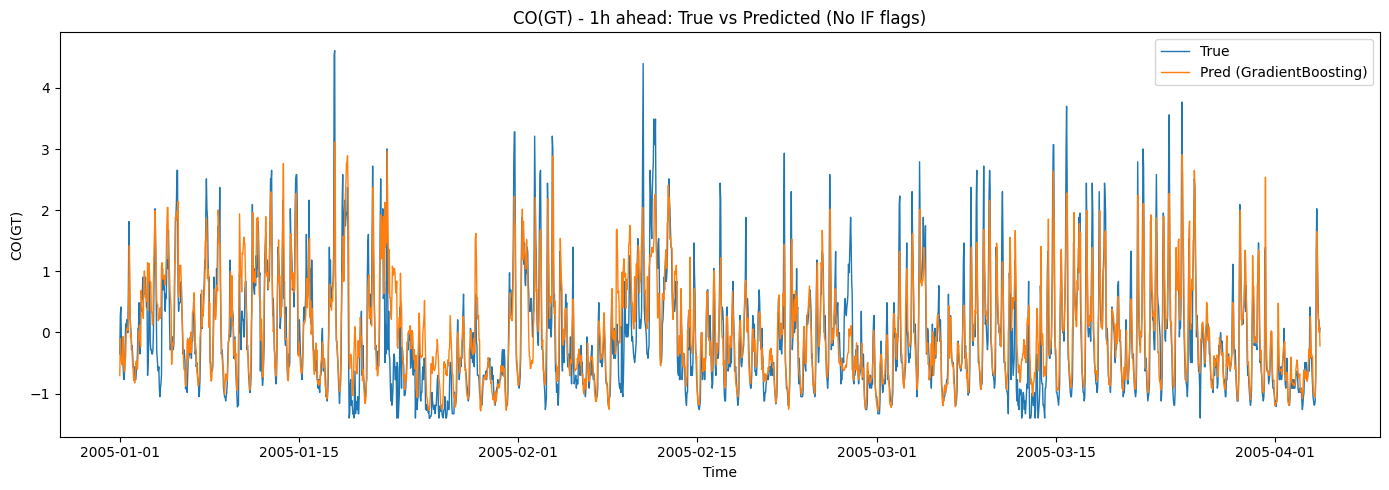

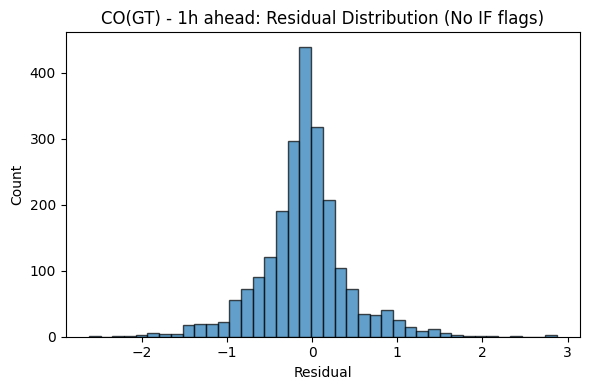

In [4]:
if pred_curves:
    example_key = list(pred_curves.keys())[0]
    example_target, example_horizon = example_key
    pc = pred_curves[example_key]
    time_axis, y_true, y_pred = pc['time'], pc['y_true'], pc['y_pred']

    plt.figure(figsize=(14, 5))
    plt.plot(time_axis, y_true, label='True', linewidth=1)
    plt.plot(time_axis, y_pred, label='Pred (GradientBoosting)', linewidth=1)
    plt.title(f"{example_target} - {example_horizon}h ahead: True vs Predicted (No IF flags)")
    plt.xlabel('Time')
    plt.ylabel(example_target)
    plt.legend()
    plt.tight_layout()
    plt.savefig(fig_dir / f"{example_target.replace('(GT)','').lower()}_{example_horizon}h_true_vs_pred.png", dpi=150)
    plt.show()

    residuals = y_true - y_pred
    plt.figure(figsize=(6, 4))
    plt.hist(residuals, bins=40, edgecolor='k', alpha=0.7)
    plt.title(f"{example_target} - {example_horizon}h ahead: Residual Distribution (No IF flags)")
    plt.xlabel('Residual')
    plt.ylabel('Count')
    plt.tight_layout()
    plt.savefig(fig_dir / f"{example_target.replace('(GT)','').lower()}_{example_horizon}h_residuals.png", dpi=150)
    plt.show()
else:
    print('No prediction curves stored.')


Feature importance (RandomForest) for the same example horizon (no IF flags).

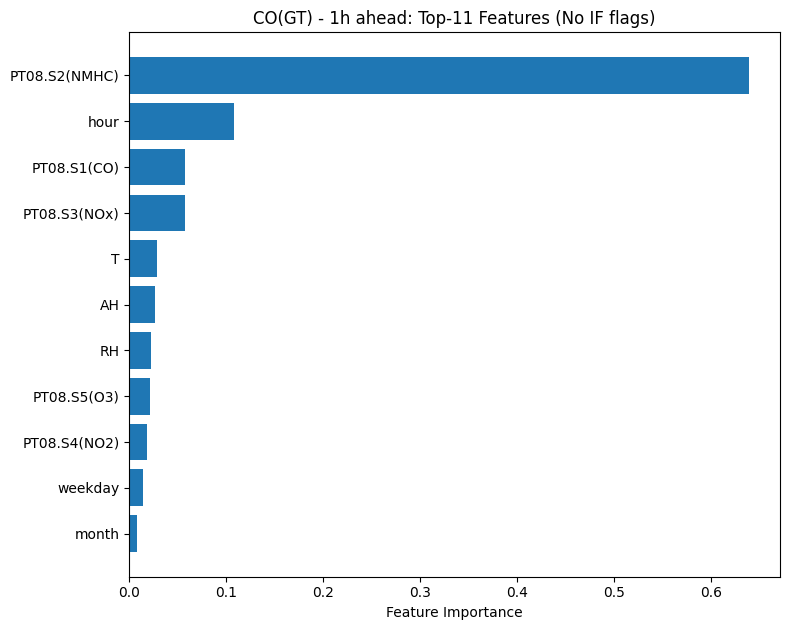

In [5]:
if pred_curves:
    tgt, h = list(pred_curves.keys())[0]
    label_col = f"{tgt}_t_plus_{h}"
    df_imp = df.copy()
    df_imp[label_col] = df_imp[tgt].shift(-h)
    df_imp = df_imp.dropna(subset=[label_col])
    used_feature_cols = [c for c in base_feature_cols if c in df_imp.columns]
    df_imp = df_imp[used_feature_cols + [label_col]].sort_index()
    splits_imp = chronological_split(df_imp, [label_col])
    X_train_imp = splits_imp['X_train']
    y_train_imp = splits_imp['y_train'][label_col]

    rf = RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1)
    imp_imputer = SimpleImputer(strategy='median')
    X_train_imp_imputed = imp_imputer.fit_transform(X_train_imp)
    rf.fit(X_train_imp_imputed, y_train_imp)

    importances = rf.feature_importances_
    indices = np.argsort(importances)[::-1]
    top_k = min(20, len(used_feature_cols))

    plt.figure(figsize=(8, 0.4 * top_k + 2))
    plt.barh(range(top_k), importances[indices[:top_k]][::-1])
    plt.yticks(range(top_k), [used_feature_cols[i] for i in indices[:top_k]][::-1])
    plt.xlabel('Feature Importance')
    plt.title(f"{tgt} - {h}h ahead: Top-{top_k} Features (No IF flags)")
    plt.tight_layout()
    plt.savefig(fig_dir / f"{tgt.replace('(GT)','').lower()}_{h}h_feature_importance.png", dpi=150)
    plt.show()
else:
    print('No prediction curves stored for feature importance.')
